# Step 4 — Regression Analysis: Impact of Skills on Salary

Builds a multiple linear regression model for log-salary vs. skills + background predictors:

$$\ln(W_i) = \alpha + \sum_j \beta_j \cdot S_{ij} + \sum_k \gamma_k \cdot X_{ik} + \varepsilon_i$$

**Sample:** Djinni parent vacancies with declared salary.

**Why Djinni-only?** DOU does not publish structured fields for years of experience or English level. Restricting to Djinni yields a homogeneous sample with no need for missing-value imputation, ensuring cleaner methodology.

**Predictors:**
- `S_ij` — binary indicator of skill `j` (≥ 50 occurrences in the sample)
- `X_ik` — experience (years), English level (CEFR), category

**Outputs:**
- `regression_results.csv` — coefficient table
- `regression_summary.txt` — full statsmodels summary
- `regression_top_skills.png` — bar chart of significant skills

## 1. Setup

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings
warnings.simplefilter('ignore', category=FutureWarning)

INPUT_PATH = 'path/to/step3_vacancies_with_skills.parquet'
OUT_DIR    = '/kaggle/working'
os.makedirs(OUT_DIR, exist_ok=True)

## 2. Load Data and Filter to Djinni Vacancies with Salary

In [2]:
df = pd.read_parquet(INPUT_PATH)
print(f'Total parents: {len(df):,}')

df['salary_mid'] = (df['public_salary_min'] + df['public_salary_max']) / 2

ds = df[(df['source'] == 'djinni') & df['salary_mid'].notna()].copy()
ds = ds[(ds['salary_mid'] >= 200) & (ds['salary_mid'] <= 20000)].copy()
ds['log_salary'] = np.log(ds['salary_mid'])

print(f'Djinni with declared salary, in range [200, 20000] USD: {len(ds):,}')
print(f'\nSalary distribution (USD/month):')
print(ds['salary_mid'].describe().round(0))

Total parents: 27,720
Djinni with declared salary, in range [200, 20000] USD: 2,618

Salary distribution (USD/month):
count     2618.0
mean      2617.0
std       2081.0
min        200.0
25%       1100.0
50%       2000.0
75%       3500.0
max      17500.0
Name: salary_mid, dtype: float64


## 3. Prepare Predictors

### 3.1 Skills (one-hot encoding, ≥ 50 occurrences)

In [3]:
from collections import Counter

skill_counter = Counter()
for s_list in ds['skills']:
    skill_counter.update(s_list)

MIN_SKILL_COUNT = 50
popular_skills = sorted([s for s, c in skill_counter.items() if c >= MIN_SKILL_COUNT])
print(f'Popular skills (≥{MIN_SKILL_COUNT}): {len(popular_skills)}')

skill_matrix = pd.DataFrame(
    {f'skill_{s}': ds['skills'].apply(lambda lst: int(s in lst)) for s in popular_skills},
    index=ds.index,
)

Popular skills (≥50): 48


### 3.2 Background predictors: experience, English level, category

In [4]:
# Normalize English to CEFR levels
ENGLISH_MAP = {
    'No English': 'None', 'None': 'None', '': 'None',
    'A1 - Beginner': 'A1', 'A1 - Початківець': 'A1', 'Beginner/Elementary': 'A1',
    'A2 - Elementary': 'A2', 'A2 - Елементарний': 'A2',
    'B1 - Intermediate': 'B1', 'B1 – Середній': 'B1',
    'Intermediate': 'B1', 'Pre-Intermediate': 'B1',
    'B2 - Upper Intermediate': 'B2', 'B2 – Вище середнього': 'B2',
    'Upper-Intermediate': 'B2',
    'C1 - Advanced': 'C1', 'C1 – Просунутий': 'C1', 'Advanced/Fluent': 'C1',
    'C2 - Proficient': 'C2', 'C2 – Вільний': 'C2', 'Native': 'C2',
}
ds['english_cefr'] = ds['english'].astype(str).map(ENGLISH_MAP).fillna('Unknown')
english_dummies = pd.get_dummies(ds['english_cefr'], prefix='eng', drop_first=True).astype(int)

top_categories = ds['category'].value_counts().head(20).index.tolist()
ds['category_grouped'] = ds['category'].where(ds['category'].isin(top_categories), 'Other_cat')
category_dummies = pd.get_dummies(ds['category_grouped'], prefix='cat', drop_first=True).astype(int)

print(f'English distribution:')
print(ds['english_cefr'].value_counts())
print(f'\nTop categories: {len(top_categories)}')

English distribution:
english_cefr
B2      951
B1      592
None    581
C1      253
A2      158
A1       52
C2       31
Name: count, dtype: int64

Top categories: 20


## 4. Fit the Model

In [5]:
X = pd.concat([
    skill_matrix,
    ds[['experience']],
    english_dummies,
    category_dummies,
], axis=1).astype(float)

X = sm.add_constant(X)
y = ds['log_salary']

print(f'Design matrix: {X.shape[0]} observations × {X.shape[1]} predictors')

model = sm.OLS(y, X).fit()
print(f'\nR² = {model.rsquared:.4f}')
print(f'Adjusted R² = {model.rsquared_adj:.4f}')
print(f'F-statistic = {model.fvalue:.2f}, p-value = {model.f_pvalue:.2e}')
print(f'N = {int(model.nobs)}')

Design matrix: 2618 observations × 76 predictors

R² = 0.5865
Adjusted R² = 0.5743
F-statistic = 48.06, p-value = 0.00e+00
N = 2618


## 5. Extract and Save Skill Coefficients

Each coefficient $\beta_j$ is interpreted as approximate **percentage change** in salary. Exact effect: $e^{\beta_j} - 1$.

In [6]:
summary = pd.DataFrame({
    'predictor': model.params.index,
    'coef':      model.params.values,
    'std_err':   model.bse.values,
    'p_value':   model.pvalues.values,
    'ci_low':    model.conf_int()[0].values,
    'ci_high':   model.conf_int()[1].values,
})
summary['pct_effect'] = (np.exp(summary['coef']) - 1) * 100

skill_results = summary[summary['predictor'].str.startswith('skill_')].copy()
skill_results['skill'] = skill_results['predictor'].str.replace('skill_', '', regex=False)
skill_results = skill_results[['skill', 'coef', 'pct_effect', 'std_err', 'p_value', 'ci_low', 'ci_high']]
skill_results = skill_results.sort_values('coef', ascending=False).reset_index(drop=True)

skill_results.to_csv(f'{OUT_DIR}/regression_results.csv', index=False)
with open(f'{OUT_DIR}/regression_summary.txt', 'w') as f:
    f.write(str(model.summary()))

print('Top 20 skills by positive salary impact:')
print(skill_results.head(20).to_string(index=False))
print('\nBottom 10 (negative impact):')
print(skill_results.tail(10).to_string(index=False))

Top 20 skills by positive salary impact:
       skill     coef  pct_effect  std_err  p_value    ci_low  ci_high
  TensorFlow 0.238310   26.910206 0.119647 0.046502  0.003695 0.472924
        Java 0.190428   20.976678 0.068337 0.005366  0.056425 0.324430
Facebook Ads 0.158932   17.225829 0.100085 0.112418 -0.037325 0.355189
         C++ 0.153504   16.591283 0.068924 0.026024  0.018352 0.288657
      Python 0.131113   14.009605 0.039378 0.000882  0.053895 0.208330
       Kafka 0.130174   13.902606 0.065479 0.046917  0.001776 0.258571
  Kubernetes 0.116131   12.314257 0.040869 0.004525  0.035992 0.196270
          Go 0.111136   11.754649 0.097072 0.252367 -0.079212 0.301484
  Google Ads 0.095328   10.001972 0.102440 0.352163 -0.105547 0.296203
         CSS 0.085655    8.943044 0.188362 0.649339 -0.283704 0.455015
         GCP 0.081279    8.467382 0.056117 0.147630 -0.028760 0.191319
          C# 0.078050    8.117619 0.074388 0.294173 -0.067817 0.223916
       Redis 0.064954    6.710967 0.

## 6. Bar Chart: Statistically Significant Skills (p < 0.05)

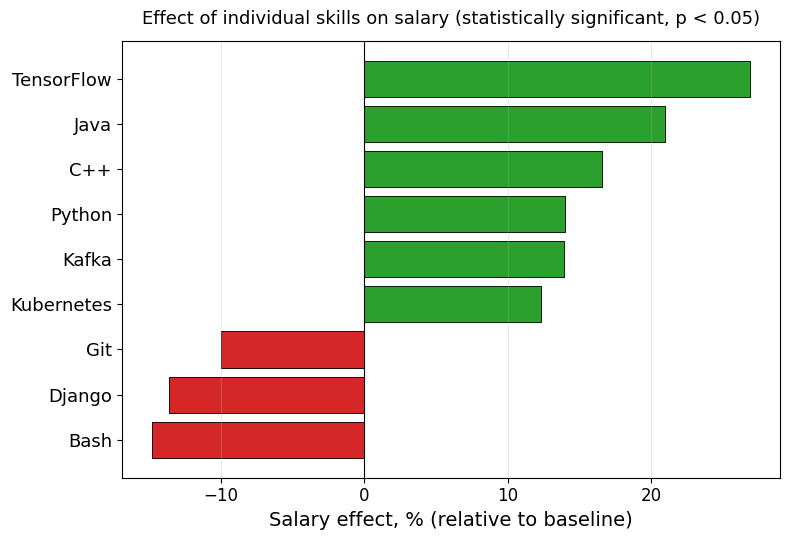

Saved: /kaggle/working/regression_top_skills.png


In [7]:
significant = skill_results[skill_results['p_value'] < 0.05].copy()
top_pos = significant.head(15).iloc[::-1]
top_neg = significant.tail(10).iloc[::-1]
to_plot = pd.concat([top_neg, top_pos])

fig, ax = plt.subplots(figsize=(8, 5.5))
colors = ['#d62728' if v < 0 else '#2ca02c' for v in to_plot['pct_effect']]
ax.barh(to_plot['skill'], to_plot['pct_effect'], color=colors, edgecolor='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)

ax.set_xlabel('Salary effect, % (relative to baseline)', fontsize=14)
ax.set_title('Effect of individual skills on salary (statistically significant, p < 0.05)', fontsize=13, pad=12)
ax.tick_params(axis='y', labelsize=13)
ax.tick_params(axis='x', labelsize=12)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/regression_top_skills.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT_DIR}/regression_top_skills.png')

## 7. Background Predictor Effects

In [8]:
background = summary[~summary['predictor'].str.startswith('skill_')].copy()
background = background[background['predictor'] != 'const']
background = background.sort_values('coef', ascending=False)

print('Background predictor effects:')
print(background[['predictor', 'coef', 'pct_effect', 'p_value']].to_string(index=False))

Background predictor effects:
          predictor      coef  pct_effect       p_value
     cat_Head Chief  0.427619   53.360218  1.205265e-04
         experience  0.269078   30.875747 9.000717e-242
             eng_C1  0.125442   13.364938  1.259016e-01
             eng_B2  0.059218    6.100604  4.339622e-01
           eng_None  0.017401    1.755320  8.189607e-01
         cat_DevOps -0.002704   -0.270044  9.794265e-01
             eng_C2 -0.041634   -4.077936  7.297222e-01
             eng_B1 -0.051830   -5.050932  4.951264e-01
  cat_Data Engineer -0.071562   -6.906180  5.144171e-01
   cat_Data Science -0.099971   -9.513647  3.112752e-01
          cat_Sales -0.102986   -9.786019  2.847714e-01
      cat_Fullstack -0.125461  -11.790958  2.462807e-01
      cat_Marketing -0.144214  -13.429713  1.186731e-01
       cat_Finances -0.189949  -17.299830  1.232836e-01
      cat_Other_cat -0.197689  -17.937500  2.813336e-02
             eng_A2 -0.208170  -18.793131  1.316613e-02
         cat_Pytho

## 8. Summary Block for the Report (Section 3.7)

In [9]:
n_sig_pos = ((skill_results['p_value'] < 0.05) & (skill_results['coef'] > 0)).sum()
n_sig_neg = ((skill_results['p_value'] < 0.05) & (skill_results['coef'] < 0)).sum()
top3 = skill_results.head(3)

print('=' * 60)
print('FOR THE REPORT (Section 3.7)')
print('=' * 60)
print(f'Sample size:                  N = {int(model.nobs):,} (Djinni only)')
print(f'Skills in model:              {len(popular_skills)}')
print(f'R²:                           {model.rsquared:.4f}')
print(f'Adjusted R²:                  {model.rsquared_adj:.4f}')
print(f'F-statistic:                  {model.fvalue:.2f}')
print(f'F-test p-value:               {model.f_pvalue:.2e}')
print(f'Skills with significant +effect (p<0.05): {n_sig_pos}')
print(f'Skills with significant –effect (p<0.05): {n_sig_neg}')
print()
print(f'Top 3 skills by salary premium:')
for _, r in top3.iterrows():
    print(f'  {r["skill"]:<25} +{r["pct_effect"]:.1f}%  (p={r["p_value"]:.4f})')

FOR THE REPORT (Section 3.7)
Sample size:                  N = 2,618 (Djinni only)
Skills in model:              48
R²:                           0.5865
Adjusted R²:                  0.5743
F-statistic:                  48.06
F-test p-value:               0.00e+00
Skills with significant +effect (p<0.05): 6
Skills with significant –effect (p<0.05): 3

Top 3 skills by salary premium:
  TensorFlow                +26.9%  (p=0.0465)
  Java                      +21.0%  (p=0.0054)
  Facebook Ads              +17.2%  (p=0.1124)
